In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')
sns.set(style='white')


In [2]:
# Reading dataset
data_m = pd.read_csv('Manufacturing Dataset New.csv')

In [3]:
data_m.head()

,Production_ID,Date,Product_Type,Machine_ID,Shift,Units_Produced,Defects,Production_Time_Hours,Material_Cost_Per_Unit,Labour_Cost_Per_Hour,Energy_Consumption_kWh,Operator_Count,Maintenance_Hours,Down_time_Hours,Production_Volume_Cubic_Meters,Scrap_Rate,Rewor_Hours,Quality_Checks_Failed,Average_Temperature_C,Average_Humidity_Percent
0,1899-12-31,01-01-2020,Automotive,3,Swing,142,3.0,23.42,38.68,15.38,413.97,1,4.86,1.57,2.34,0.048,1.65,1,22.8,47.2
1,01-01-1900,02-01-2020,Textiles,8,Night,170,4.0,7.51,21.35,25.36,181.16,2,2.51,0.18,1.52,0.030,NaN,1,23.8,37.9
2,02-01-1900,03-01-2020,Appliances,11,Swing,182,4.0,20.58,47.54,16.46,452.15,2,0.34,2.88,0.57,0.026,0.26,0,24.5,56.1
3,03-01-1900,04-01-2020,Appliances,11,Day,133,NaN,21.68,40.21,28.70,485.78,3,4.64,2.23,1.90,0.036,NaN,2,22.3,50.8
4,04-01-1900,05-01-2020,Electronics,14,Night,82,NaN,16.68,38.02,17.20,315.58,1,2.29,0.02,2.25,0.020,0.67,0,23.4,53.9


In [4]:
# lets check no of colunms and rows
data_m.shape

(3000, 20)

In [5]:
# lets have look on colunms of dataset
data_m.columns

Index(['Production_ID', 'Date', 'Product_Type', 'Machine_ID', 'Shift',
       'Units_Produced', 'Defects', 'Production_Time_Hours',
       'Material_Cost_Per_Unit', 'Labour_Cost_Per_Hour',
       'Energy_Consumption_kWh', 'Operator_Count', 'Maintenance_Hours',
       'Down_time_Hours', 'Production_Volume_Cubic_Meters', 'Scrap_Rate',
       'Rewor_Hours', 'Quality_Checks_Failed', 'Average_Temperature_C',
       'Average_Humidity_Percent'],
      dtype='object')

In [6]:
# droping production_id colunm
data_m.drop(columns=['Production_ID'], inplace=True)

In [7]:
data_m.head()

,Date,Product_Type,Machine_ID,Shift,Units_Produced,Defects,Production_Time_Hours,Material_Cost_Per_Unit,Labour_Cost_Per_Hour,Energy_Consumption_kWh,Operator_Count,Maintenance_Hours,Down_time_Hours,Production_Volume_Cubic_Meters,Scrap_Rate,Rewor_Hours,Quality_Checks_Failed,Average_Temperature_C,Average_Humidity_Percent
0,01-01-2020,Automotive,3,Swing,142,3.0,23.42,38.68,15.38,413.97,1,4.86,1.57,2.34,0.048,1.65,1,22.8,47.2
1,02-01-2020,Textiles,8,Night,170,4.0,7.51,21.35,25.36,181.16,2,2.51,0.18,1.52,0.030,NaN,1,23.8,37.9
2,03-01-2020,Appliances,11,Swing,182,4.0,20.58,47.54,16.46,452.15,2,0.34,2.88,0.57,0.026,0.26,0,24.5,56.1
3,04-01-2020,Appliances,11,Day,133,NaN,21.68,40.21,28.70,485.78,3,4.64,2.23,1.90,0.036,NaN,2,22.3,50.8
4,05-01-2020,Electronics,14,Night,82,NaN,16.68,38.02,17.20,315.58,1,2.29,0.02,2.25,0.020,0.67,0,23.4,53.9


In [8]:
# lets check data types od each column.
data_m.dtypes

Date                               object
Product_Type                       object
Machine_ID                          int64
Shift                              object
Units_Produced                      int64
Defects                           float64
Production_Time_Hours             float64
Material_Cost_Per_Unit            float64
Labour_Cost_Per_Hour              float64
Energy_Consumption_kWh            float64
Operator_Count                      int64
Maintenance_Hours                 float64
Down_time_Hours                   float64
Production_Volume_Cubic_Meters    float64
Scrap_Rate                        float64
Rewor_Hours                       float64
Quality_Checks_Failed               int64
Average_Temperature_C             float64
Average_Humidity_Percent          float64
dtype: object

In [9]:
# Checking all int64 data types.
data_m.dtypes[data_m.dtypes == 'int64' ]

Machine_ID               int64
Units_Produced           int64
Operator_Count           int64
Quality_Checks_Failed    int64
dtype: object

In [10]:
# Checking all float data types.
data_m.dtypes[data_m.dtypes == 'float' ]

Defects                           float64
Production_Time_Hours             float64
Material_Cost_Per_Unit            float64
Labour_Cost_Per_Hour              float64
Energy_Consumption_kWh            float64
Maintenance_Hours                 float64
Down_time_Hours                   float64
Production_Volume_Cubic_Meters    float64
Scrap_Rate                        float64
Rewor_Hours                       float64
Average_Temperature_C             float64
Average_Humidity_Percent          float64
dtype: object

In [11]:
# # Checking all object data types.
data_m.dtypes[data_m.dtypes == 'object' ]

Date            object
Product_Type    object
Shift           object
dtype: object

In [12]:
# setting object data tpyes as category.
data_m['Product_Type'] = data_m['Product_Type'].astype('category')
data_m['Shift'] = data_m['Shift'].astype('category')
data_m['Date'] = data_m['Date'].astype('category')

In [13]:
# creating values which will have all numerical columns
numerical_cols = data_m.select_dtypes(include = ['float','int64']).columns

numerical_cols

Index(['Machine_ID', 'Units_Produced', 'Defects', 'Production_Time_Hours',
       'Material_Cost_Per_Unit', 'Labour_Cost_Per_Hour',
       'Energy_Consumption_kWh', 'Operator_Count', 'Maintenance_Hours',
       'Down_time_Hours', 'Production_Volume_Cubic_Meters', 'Scrap_Rate',
       'Rewor_Hours', 'Quality_Checks_Failed', 'Average_Temperature_C',
       'Average_Humidity_Percent'],
      dtype='object')

In [14]:
# Checkimg maximum value for each nuemrical column.
data_m[numerical_cols].max()

Machine_ID                         20.00
Units_Produced                    199.00
Defects                            34.00
Production_Time_Hours              50.00
Material_Cost_Per_Unit             65.00
Labour_Cost_Per_Hour               30.00
Energy_Consumption_kWh            499.96
Operator_Count                      4.00
Maintenance_Hours                   5.00
Down_time_Hours                     3.00
Production_Volume_Cubic_Meters      2.50
Scrap_Rate                          0.05
Rewor_Hours                         2.00
Quality_Checks_Failed               2.00
Average_Temperature_C              25.00
Average_Humidity_Percent           60.00
dtype: float64

In [15]:
# Checkimg minimum value for each nuemrical column.
data_m[numerical_cols].min()

Machine_ID                          1.00
Units_Produced                     50.00
Defects                             0.00
Production_Time_Hours               1.00
Material_Cost_Per_Unit              3.00
Labour_Cost_Per_Hour               15.00
Energy_Consumption_kWh            100.04
Operator_Count                      1.00
Maintenance_Hours                   0.00
Down_time_Hours                     0.00
Production_Volume_Cubic_Meters      0.50
Scrap_Rate                          0.01
Rewor_Hours                         0.00
Quality_Checks_Failed               0.00
Average_Temperature_C              18.00
Average_Humidity_Percent           30.00
dtype: float64

In [16]:
data_m.describe(include =['int64','float'])

,Machine_ID,Units_Produced,Defects,Production_Time_Hours,Material_Cost_Per_Unit,Labour_Cost_Per_Hour,Energy_Consumption_kWh,Operator_Count,Maintenance_Hours,Down_time_Hours,Production_Volume_Cubic_Meters,Scrap_Rate,Rewor_Hours,Quality_Checks_Failed,Average_Temperature_C,Average_Humidity_Percent
count,3000.000000,3000.000000,2701.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,2700.000000,2700.000000,3000.000000,3000.000000,2700.000000,3000.000000,3000.000000,3000.000000
mean,10.259000,125.037667,4.612736,12.577697,30.206220,22.642937,299.895430,2.495000,2.507167,1.533941,1.512730,0.030255,1.002885,1.002667,21.601833,45.008333
std,5.752821,43.566718,3.201673,6.910378,11.726906,4.396858,114.987552,1.117911,1.444322,0.878036,0.576816,0.011467,0.578608,0.802625,2.045904,8.586297
min,1.000000,50.000000,0.000000,1.000000,3.000000,15.000000,100.040000,1.000000,0.000000,0.000000,0.500000,0.010000,0.000000,0.000000,18.000000,30.000000
25%,5.000000,86.000000,2.000000,6.797500,20.320000,18.810000,199.050000,2.000000,1.240000,0.780000,1.017500,0.020000,0.500000,0.000000,19.800000,37.500000
50%,10.000000,126.000000,4.000000,12.400000,30.045000,22.770000,300.160000,2.000000,2.490000,1.570000,1.510000,0.030000,1.010000,1.000000,21.700000,45.000000
75%,15.000000,163.000000,7.000000,18.332500,40.122500,26.492500,401.145000,4.000000,3.760000,2.300000,2.010000,0.040000,1.490000,2.000000,23.400000,52.200000
max,20.000000,199.000000,34.000000,50.000000,65.000000,30.000000,499.960000,4.000000,5.000000,3.000000,2.500000,0.050000,2.000000,2.000000,25.000000,60.000000


In [17]:
# creating function for calculating outliers.
def UNA_outlier(data, var_group):
    """
    Identifies and visualizes outliers using the Interquartile Range (IQR) method.
    
    Returns:
    - Individual boxplots for each column, each with a textual description below
    """
    
    for col in var_group:
        # Calculate IQR
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        # Define Outlier Thresholds
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Count Outliers
        outlier_high = (data[col] > upper_bound).sum()
        outlier_low = (data[col] < lower_bound).sum()

        # Create Boxplot
        plt.figure(figsize=(6, 4))  # Ensure proper figure size
        sns.boxplot(y=data[col], color="skyblue")
        plt.title(f'Boxplot of {col}')

        # Display Statistics Below Plot
        plt.figtext(0.15, -0.2, f"Column: {col}\nLower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}\nOutliers Below: {outlier_low}, Outliers Above: {outlier_high}",
                    fontsize=10, ha="left", bbox=dict(facecolor="white", edgecolor="gray", boxstyle="round,pad=0.5"))

        plt.show() 

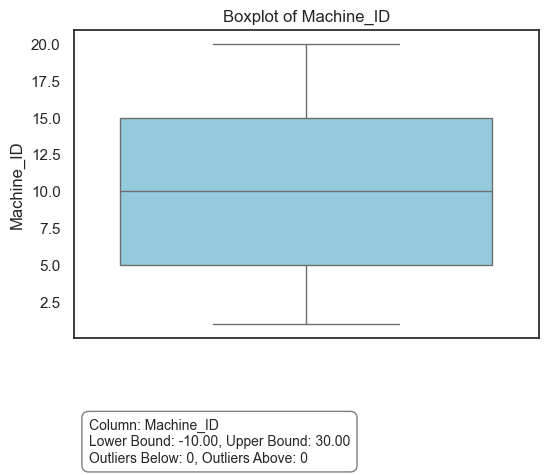

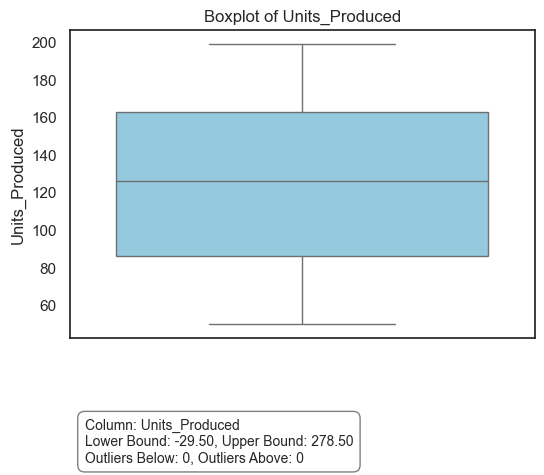

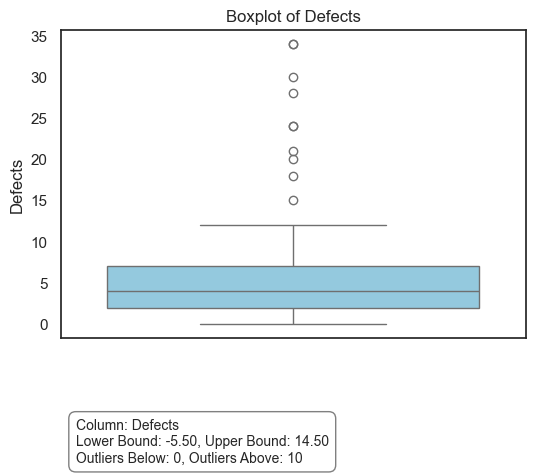

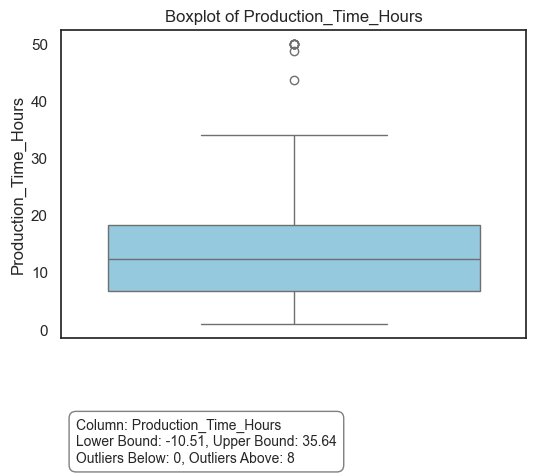

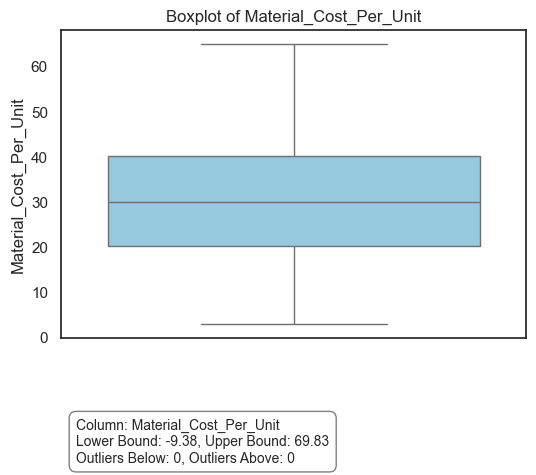

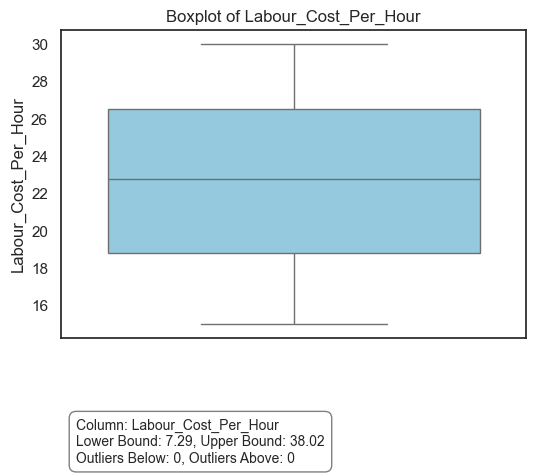

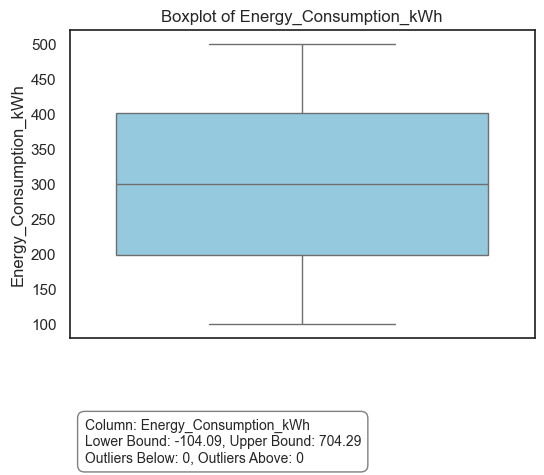

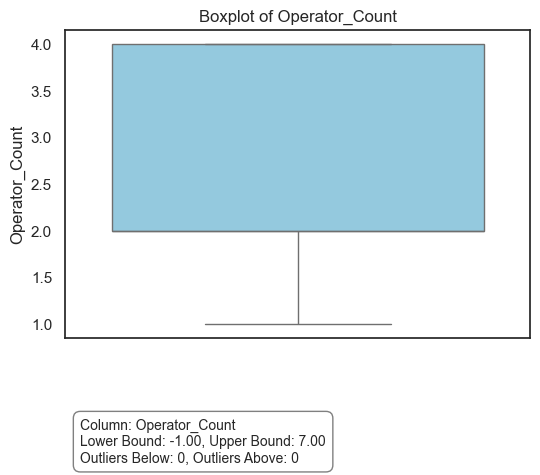

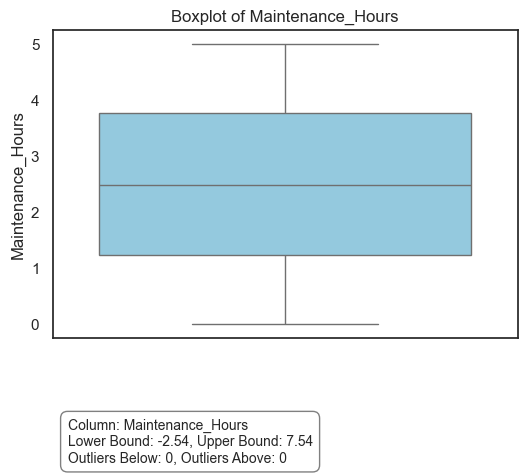

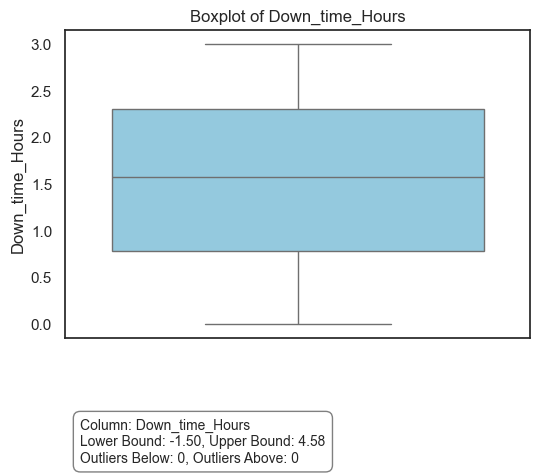

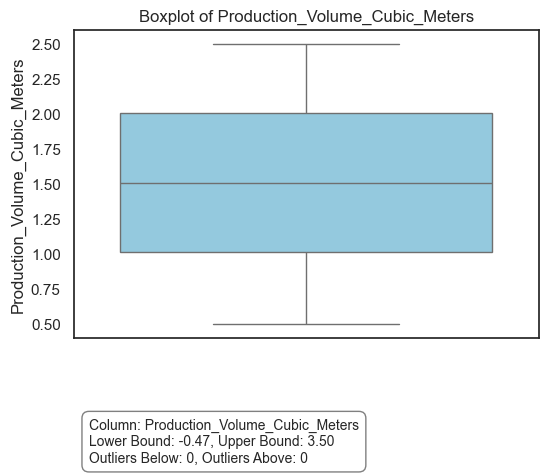

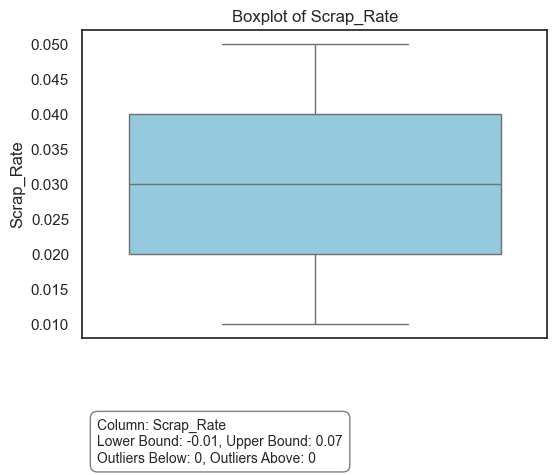

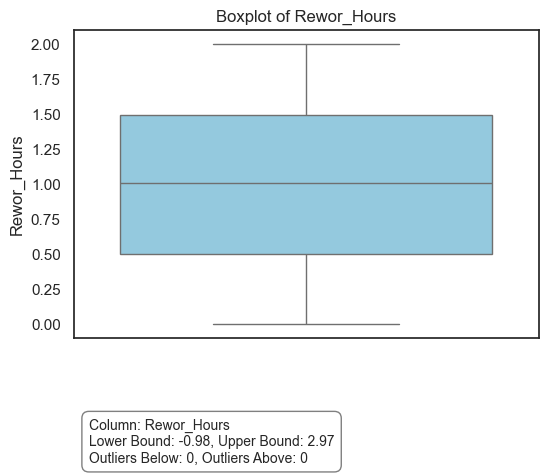

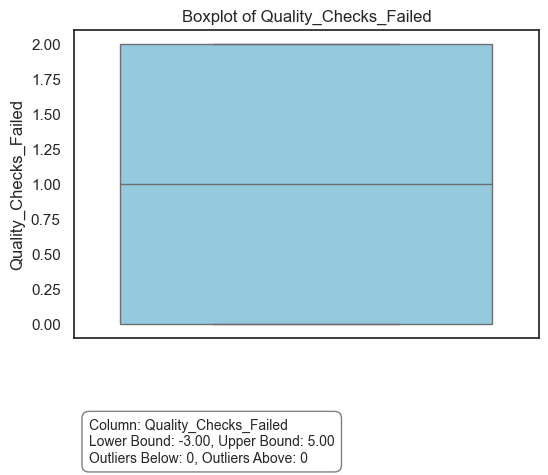

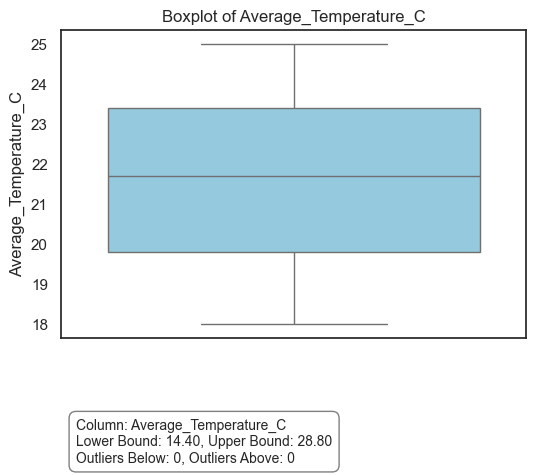

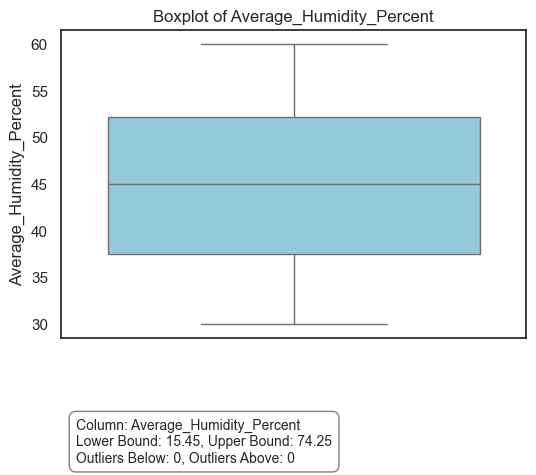

In [18]:
UNA_outlier(data_m , numerical_cols)

* Production_time_hours colunm have 8 outliers above upper bound.
* Defects colunm have 10 outliers above upper bound .

In [19]:
# lets check if there is a null value in colunms
data_m.isnull().sum()

Date                                0
Product_Type                        0
Machine_ID                          0
Shift                               0
Units_Produced                      0
Defects                           299
Production_Time_Hours               0
Material_Cost_Per_Unit              0
Labour_Cost_Per_Hour                0
Energy_Consumption_kWh              0
Operator_Count                      0
Maintenance_Hours                 300
Down_time_Hours                   300
Production_Volume_Cubic_Meters      0
Scrap_Rate                          0
Rewor_Hours                       300
Quality_Checks_Failed               0
Average_Temperature_C               0
Average_Humidity_Percent            0
dtype: int64

In [20]:
# get mean of column which have nan value
Defects_mean = data_m['Defects'].mean()
MH_mean = data_m['Maintenance_Hours'].mean()
DTH_mean = data_m['Down_time_Hours'].mean()
RH_mean = data_m['Rewor_Hours'].mean()

# replacing nan values with mean value
data_m['Defects'].fillna(Defects_mean, inplace = True)
data_m['Maintenance_Hours'].fillna(MH_mean, inplace = True)
data_m['Down_time_Hours'].fillna(DTH_mean, inplace = True)
data_m['Rewor_Hours'].fillna(RH_mean, inplace = True)

In [21]:
data_m.isnull().sum()

Date                              0
Product_Type                      0
Machine_ID                        0
Shift                             0
Units_Produced                    0
Defects                           0
Production_Time_Hours             0
Material_Cost_Per_Unit            0
Labour_Cost_Per_Hour              0
Energy_Consumption_kWh            0
Operator_Count                    0
Maintenance_Hours                 0
Down_time_Hours                   0
Production_Volume_Cubic_Meters    0
Scrap_Rate                        0
Rewor_Hours                       0
Quality_Checks_Failed             0
Average_Temperature_C             0
Average_Humidity_Percent          0
dtype: int64

#### Relationship Between Labour Costs and Material Cost :

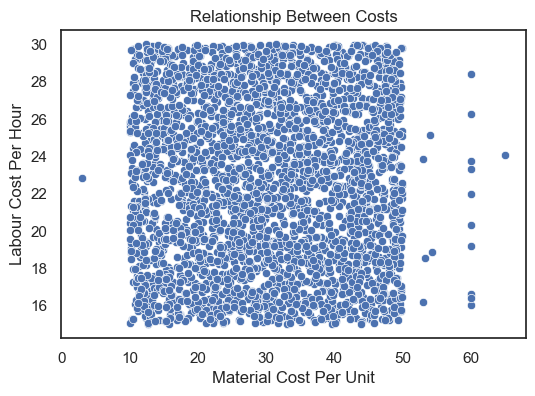

In [22]:
plt.figure(figsize=(6, 4)) 
sns.scatterplot(x= 'Material_Cost_Per_Unit', y='Labour_Cost_Per_Hour',data=data_m)
plt.title('Relationship Between Costs')
plt.xlabel('Material Cost Per Unit')
plt.ylabel('Labour Cost Per Hour')
plt.show()

In [23]:
# performing pearson correlation :
correlation = data_m['Material_Cost_Per_Unit'].corr(data_m['Labour_Cost_Per_Hour'])
print(f" Person Correlation Coefficient: {correlation:.2f}")


 Person Correlation Coefficient: -0.00


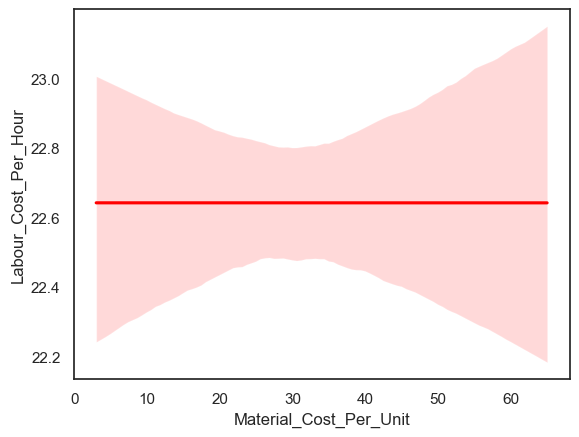

In [24]:
sns.regplot(x=data_m['Material_Cost_Per_Unit'], y=data_m['Labour_Cost_Per_Hour'], scatter=False, color='red')
plt.show()

* Line slope is flat we can confirn there is no strong association between labour cost per hour and Material cost per unit.

---
#### Lets Check Efficiency Across Shifts :
---

---
Yes, to calculate overall production time, sum the Rework hours, Downtime hours, and Maintenance hours.  
---

In [25]:
# Calculating Mean of production time and energy consumption for each shifts.
grouped_df = data_m.groupby('Shift', as_index=False)[['Production_Time_Hours','Energy_Consumption_kWh']].mean(numeric_only=True)
print(grouped_df)

   Shift  Production_Time_Hours  Energy_Consumption_kWh
0    Day              12.595652              298.903686
1  Night              12.524242              302.865897
2  Swing              12.613677              297.890168


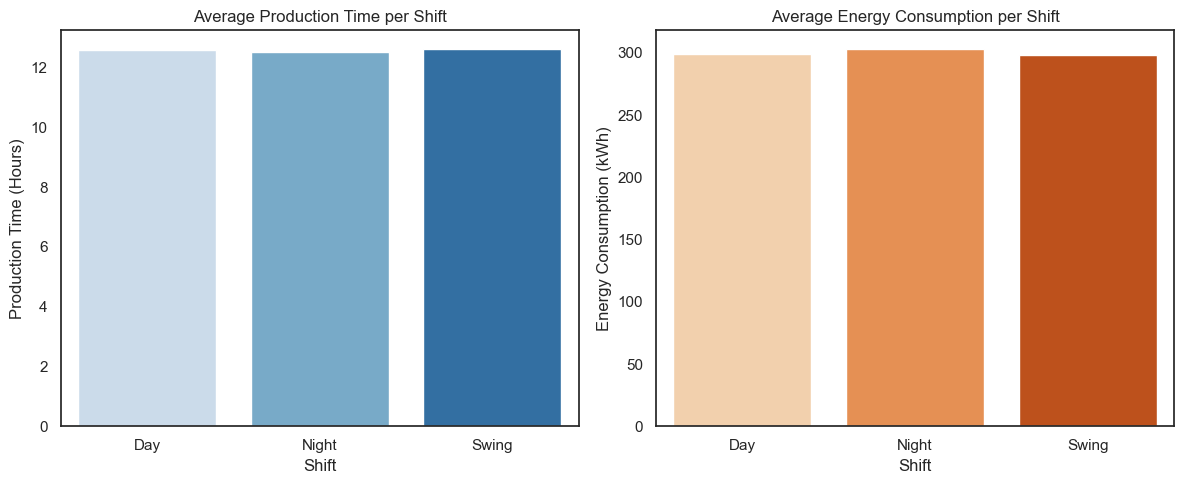

In [26]:
plt.figure(figsize=(12, 5))

# Average Production Time Hours per Shift
plt.subplot(1, 2, 1)
sns.barplot(x="Shift", y="Production_Time_Hours", data=grouped_df, palette="Blues")
plt.title("Average Production Time per Shift")
plt.ylabel("Production Time (Hours)")
plt.xlabel("Shift")

# Average Energy Consumption per Shift
plt.subplot(1, 2, 2)
sns.barplot(x="Shift", y="Energy_Consumption_kWh", data=grouped_df, palette="Oranges")
plt.title("Average Energy Consumption per Shift")
plt.ylabel("Energy Consumption (kWh)")
plt.xlabel("Shift")

plt.tight_layout()
plt.show()

## Monthly Production Trends :

In [27]:
# extracting the month of year and Year from the Date colunm
data_m['Date'] = pd.to_datetime(data_m['Date'], dayfirst=True)  
data_m['moy'] = data_m['Date'].dt.month
data_m['Year'] = data_m['Date'].dt.year

In [28]:
data_m[['moy','Year']].head(10)

,moy,Year
0,1,2020
1,1,2020
2,1,2020
3,1,2020
4,1,2020
5,1,2020
6,1,2020
7,1,2020
8,1,2020
9,1,2020


In [29]:
# lets calculate Average unit production of months
monthly_avg_production = data_m.groupby(['moy'])['Units_Produced'].mean().reset_index()

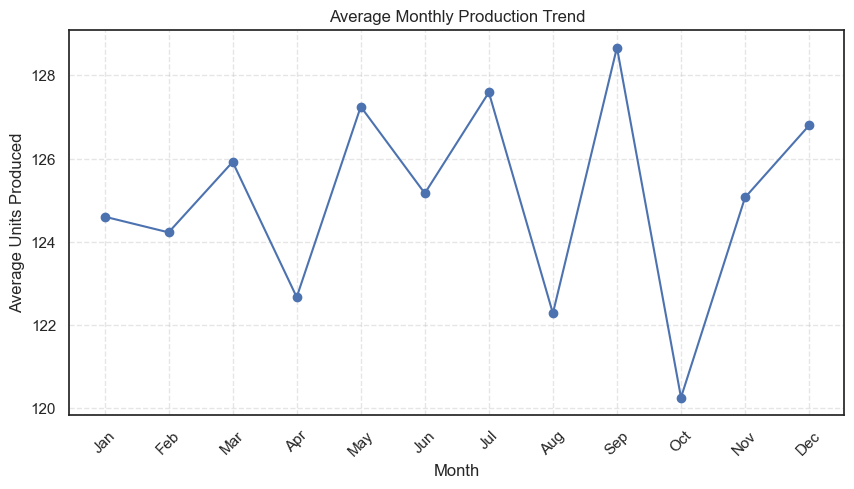

In [30]:
# ploting the grap for Monthly Avg Production.
plt.figure(figsize=(10,5))
plt.plot(monthly_avg_production['moy'],monthly_avg_production['Units_Produced'], marker='o', linestyle='-', color='b')
plt.xticks(ticks=range(1,13),labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"], rotation=45)
plt.xlabel('Month')
plt.ylabel('Average Units Produced')
plt.title('Average Monthly Production Trend')
plt.grid(True, linestyle = '--', alpha=0.5)

plt.show()


---

#### Above Graph represents the average monthly production trend across all years

---

In [31]:
# Year On Year Trend Analysis :
Yearly_Trend = data_m.groupby(['Year', 'moy'])['Units_Produced'].mean().reset_index()

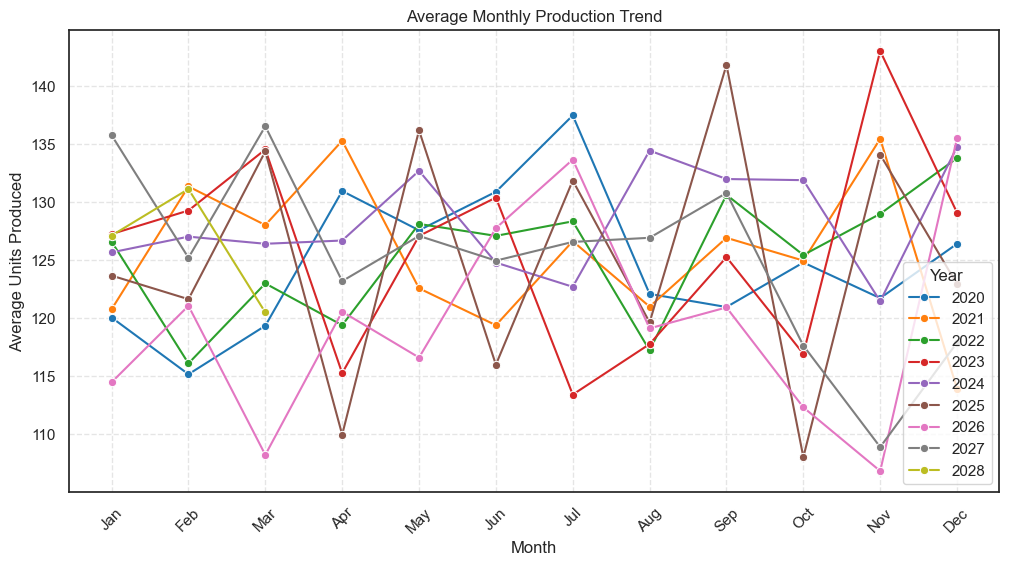

In [32]:
# graph for year on year trend of unit produced monthly
plt.figure(figsize=(12, 6))
sns.lineplot(data=Yearly_Trend, x="moy", y="Units_Produced", hue="Year", marker="o", palette="tab10")

plt.xticks(ticks=range(1,13),labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"], rotation=45)
plt.xlabel('Month')
plt.ylabel('Average Units Produced')
plt.title('Average Monthly Production Trend')
plt.grid(True, linestyle = '--', alpha=0.5)
plt.show()

* No Particular Trend was seen all years.
* Mixed Trend has been seen across years.

---
#### Check Variability In Production BY Product Type:
---

In [33]:
std_d_prod = data_m.groupby(['Product_Type'])['Production_Volume_Cubic_Meters'].std()
print(std_d_prod)

Product_Type
Appliances     0.602654
Automotive     0.561560
Electronics    0.573125
Furniture      0.579365
Textiles       0.567891
Name: Production_Volume_Cubic_Meters, dtype: float64


---
#### Role Of Operator In Efficiency :
---

In [34]:
eff_count = data_m.groupby(['Operator_Count', 'Units_Produced'])['Production_Time_Hours'].mean().reset_index()
print(eff_count)

     Operator_Count  Units_Produced  Production_Time_Hours
0                 1              50              14.836667
1                 1              51              13.580000
2                 1              52               9.281667
3                 1              53              11.362000
4                 1              54              14.408000
..              ...             ...                    ...
590               4             195              11.264286
591               4             196               9.126667
592               4             197               6.638000
593               4             198              10.187143
594               4             199               8.053333

[595 rows x 3 columns]


In [35]:
data_m['Operator_Count'].value_counts()

Operator_Count
2    770
4    751
1    748
3    731
Name: count, dtype: int64

In [36]:
eff_count = data_m.groupby('Operator_Count').apply(
    lambda x: (x['Units_Produced'].sum() / x['Production_Time_Hours'].sum())).reset_index( 
    name='Avg_Units_Per_Hour')

print(eff_count)

   Operator_Count  Avg_Units_Per_Hour
0               1            9.918450
1               2            9.722629
2               3           10.115330
3               4           10.026795


---
#### Identifying The Machine With Most Defects
---

In [39]:
data_m['defect_rate'] = (data_m['Defects'] / data_m['Units_Produced']) * 100
defect_rate_per_machine = data_m.groupby('Machine_ID')['defect_rate'].mean().reset_index()
machine_higdef = defect_rate_per_machine.loc[defect_rate_per_machine['defect_rate'].idxmax()]

print("Defect rates for each machine:\n", data_m[['Machine_ID', 'defect_rate']])
print("\nMachine with the highest defect rate:\n", machine_higdef)

Defect rates for each machine:
       Machine_ID  defect_rate
0              3     2.112676
1              8     2.352941
2             11     2.197802
3             11     3.468223
4             14     5.625288
...          ...          ...
2995           3     3.608247
2996          13     3.361345
2997           9     1.176471
2998          20     1.507538
2999          12     1.652893

[3000 rows x 2 columns]

Machine with the highest defect rate:
 Machine_ID     15.000000
defect_rate     4.821455
Name: 14, dtype: float64


---
#### Lets Check Does Environment Affects Scrap Rate :
---

In [40]:
# Select relevant columns for correlation
columns_of_interest = ['Average_Temperature_C', 'Average_Humidity_Percent', 'Scrap_Rate']
data_subset = data_m[columns_of_interest]

# Calculate the correlation matrix
correlation_matrix = data_subset.corr()

# Display the correlation matrix
print("Correlation Matrix:\n", correlation_matrix)

Correlation Matrix:
                           Average_Temperature_C  Average_Humidity_Percent  \
Average_Temperature_C                  1.000000                  0.006756   
Average_Humidity_Percent               0.006756                  1.000000   
Scrap_Rate                             0.020510                  0.029378   

                          Scrap_Rate  
Average_Temperature_C       0.020510  
Average_Humidity_Percent    0.029378  
Scrap_Rate                  1.000000  


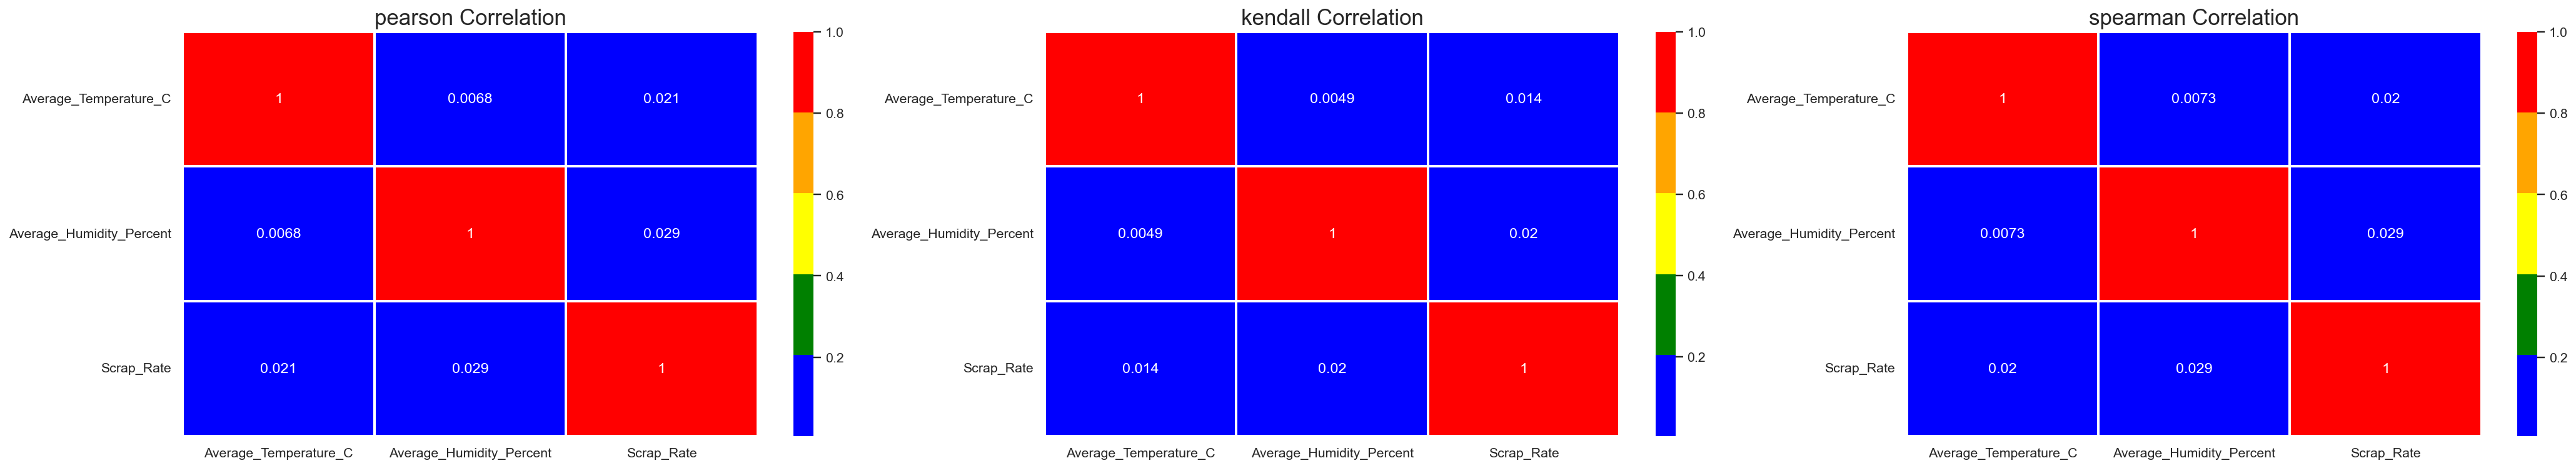

In [41]:
# Hypothesis Testing to check correlation :
from matplotlib.colors import ListedColormap

columns_of_interest = data_m[['Average_Temperature_C', 'Average_Humidity_Percent', 'Scrap_Rate']]

plt.figure(figsize=(36, 6), dpi=140)
for j, i in enumerate(['pearson', 'kendall', 'spearman']):
    plt.subplot(1, 3, j + 1)
    correlation = columns_of_interest.corr(method=i)  
    cmap = ListedColormap(["blue", "green", "yellow", "orange", "red"])
    sns.heatmap(correlation, annot=True, linewidths=2, cmap=cmap)  
    plt.title(f"{i} Correlation", fontsize=18)


* No strong correlation was seen between scrap rate and Avg Humidity Percent

---
#### Impact Of Maintenance On Downtime :
---

<Axes: xlabel='Maintenance_Hours', ylabel='Down_time_Hours'>

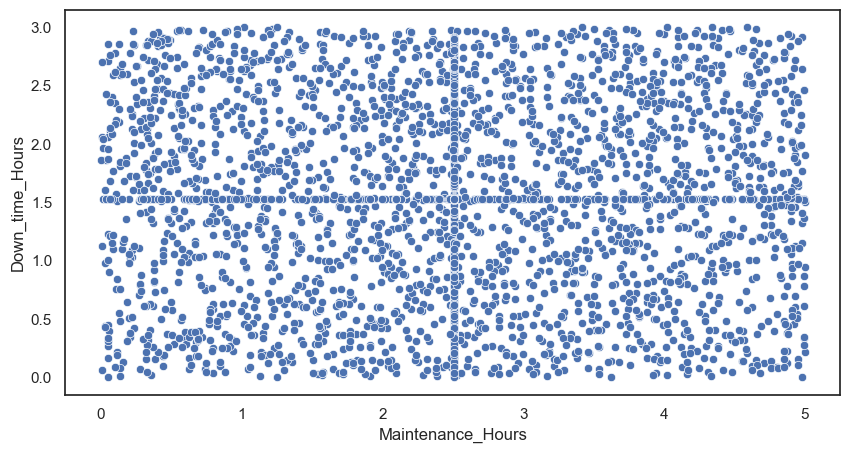

In [42]:
plt.figure(figsize=(10,5))
sns.scatterplot(x=data_m['Maintenance_Hours'], y=data_m['Down_time_Hours'])

In [ ]:
corr_md = data_m['Maintenance_Hours'].corr(data_m['Down_time_Hours'])
print(corr_md)

* No strong relationship was seen between Maintenance Hours and Down Time Hours